<a href="https://colab.research.google.com/github/wolen02/3D_human_skeleton_extrancion/blob/main/load_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CnnBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride =1):
    super(CnnBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
          nn.BatchNorm2d(out_channels)
          )

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    out += self.shortcut(x)
    out = F.relu(out)
    return out


class ResNet(nn.Module):
  def __init__(self, block, num_blocks, num_classes =17, stride=1):
    super(ResNet, self).__init__()

    self.in_channels = 3

    self.layer1 = self.make_layer(block, num_blocks[0], self.in_channels, 32, stride=1)
    self.layer2 = self.make_layer(block, num_blocks[1], self.in_channels, 64, stride=2)
    self.layer3 = self.make_layer(block, num_blocks[2], self.in_channels, 128, stride=2)
    self.layer4 = self.make_layer(block, num_blocks[3], self.in_channels, 512, stride=2)
    self.layer5 = self.make_layer(block, num_blocks[4], self.in_channels, 512, stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.bn = nn.BatchNorm2d(self.in_channels)

    self.fc = nn.Linear(self.in_channels, num_classes*3)

  def make_layer(self, block, num_blocks, in_channels, out_channels, stride=1):
    strides = [stride] + [1]*(num_blocks-1)
    layers = []
    for s in strides:
      layers.append(block(self.in_channels, out_channels, s))
      self.in_channels = out_channels
    return nn.Sequential(*layers)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    out = self.layer5(out)
    out = self.avgpool(out)
    out = out.view(out.size(0), -1)

    out = self.fc(out)
    out = out.view(out.size(0), 17, 3)
    return out

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CnnBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride =1):
    super(CnnBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
          nn.BatchNorm2d(out_channels)
          )

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    out += self.shortcut(x)
    out = F.relu(out)
    return out


class ResNet2(nn.Module):
  def __init__(self, block, num_blocks, num_classes =17, stride=1):
    super(ResNet2, self).__init__()

    self.in_channels = 3

    self.layer1 = self.make_layer(block, num_blocks[0], self.in_channels, 32, stride=1)
    self.layer2 = self.make_layer(block, num_blocks[1], self.in_channels, 64, stride=2)
    self.layer3 = self.make_layer(block, num_blocks[2], self.in_channels, 128, stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.bn = nn.BatchNorm2d(self.in_channels)

    self.fc = nn.Linear(self.in_channels, num_classes*3)

  def make_layer(self, block, num_blocks, in_channels, out_channels, stride=1):
    strides = [stride] + [1]*(num_blocks-1)
    layers = []
    for s in strides:
      layers.append(block(self.in_channels, out_channels, s))
      self.in_channels = out_channels
    return nn.Sequential(*layers)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.avgpool(out)
    out = out.view(out.size(0), -1)

    out = self.fc(out)
    out = out.view(out.size(0), 17, 3)
    return out

In [ ]:
!pip install -q plotly
!pip install -q ultralytics
!pip install -q decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 110.5 MB/s eta 0:00:00


In [ ]:
def normalize_3d_joints(joints_3d):
    """
    joints_3d: (17, 3)
    return: pelvis 기준 상대좌표, meter 단위
    """
    joints_3d = joints_3d.astype(np.float32)
    return (joints_3d - joints_3d[0:1]) / 1000.0


def preprocess_crop_for_model(crop_rgb, img_size=112):
    """
    crop_rgb: RGB image
    return: torch.Tensor, shape = (1, 3, img_size, img_size)
    """
    crop_rgb = cv2.resize(crop_rgb, (img_size, img_size))
    crop_rgb = crop_rgb.astype(np.float32) / 255.0
    crop_rgb = np.transpose(crop_rgb, (2, 0, 1))  # HWC -> CHW
    tensor = torch.tensor(crop_rgb, dtype=torch.float32).unsqueeze(0)
    return tensor

   # bbox

    def get_bbox_from_coco_keypoints(points_2d, image_width, image_height, margin=0.25):
      """
      points_2d: (17, 2) or (17, 3)
      return: np.array([x1, y1, x2, y2])
      """
      points = points_2d[:, :2].astype(np.float32)

      valid = np.isfinite(points).all(axis=1)
      valid &= points[:, 0] > 0
      valid &= points[:, 1] > 0
      valid &= points[:, 0] < image_width
      valid &= points[:, 1] < image_height

      if valid.sum() < 4:
          return np.array([0, 0, image_width, image_height], dtype=np.int32)

      pts = points[valid]

      x1, y1 = pts.min(axis=0)
      x2, y2 = pts.max(axis=0)

      bw = x2 - x1
      bh = y2 - y1

      x1 -= bw * margin
      y1 -= bh * margin
      x2 += bw * margin
      y2 += bh * margin

      x1 = int(max(0, x1))
      y1 = int(max(0, y1))
      x2 = int(min(image_width, x2))
      y2 = int(min(image_height, y2))

      if x2 <= x1 or y2 <= y1:
          return np.array([0, 0, image_width, image_height], dtype=np.int32)

      return np.array([x1, y1, x2, y2], dtype=np.int32)

      import numpy as np

def get_bbox_from_coco_keypoints(points_2d, image_width, image_height, margin=0.25):
    """
    points_2d: (17, 2) 또는 (17, 3)
    return: np.array([x1, y1, x2, y2])
    """
    points = points_2d[:, :2].astype(np.float32)

    valid = np.isfinite(points).all(axis=1)
    valid &= points[:, 0] > 0
    valid &= points[:, 1] > 0
    valid &= points[:, 0] < image_width
    valid &= points[:, 1] < image_height

    if valid.sum() < 4:
        return np.array([0, 0, image_width, image_height], dtype=np.int32)

    pts = points[valid]

    x1, y1 = pts.min(axis=0)
    x2, y2 = pts.max(axis=0)

    bw = x2 - x1
    bh = y2 - y1

    x1 -= bw * margin
    y1 -= bh * margin
    x2 += bw * margin
    y2 += bh * margin

    x1 = int(max(0, x1))
    y1 = int(max(0, y1))
    x2 = int(min(image_width, x2))
    y2 = int(min(image_height, y2))

    if x2 <= x1 or y2 <= y1:
        return np.array([0, 0, image_width, image_height], dtype=np.int32)

    return np.array([x1, y1, x2, y2], dtype=np.int32)

def collect_gt_pred_sequence(
    model,
    h36m_path,
    device,
    img_size=112,
    start_frame=0,
    max_frames=60,
    margin=0.25,
):
    """
    AthletePose3D 데이터에서 GT와 모델 예측 sequence를 수집.

    input:
        h36m_path: *_h36m.npy 경로

    return:
        gt_seq:   (T, 17, 3)
        pred_seq: (T, 17, 3)
        crop_seq: list of RGB crop images
    """

    if not h36m_path.endswith("_h36m.npy"):
        raise ValueError("h36m_path must end with '_h36m.npy'")

    mp4_path = h36m_path.replace("_h36m.npy", ".mp4")
    coco_path = h36m_path.replace("_h36m.npy", "_coco.npy")

    if not os.path.exists(mp4_path):
        raise FileNotFoundError(f"mp4 not found: {mp4_path}")

    if not os.path.exists(coco_path):
        raise FileNotFoundError(f"coco not found: {coco_path}")

    vr = VideoReader(mp4_path, ctx=cpu(0))
    gt_all = np.load(h36m_path, allow_pickle=True)
    coco_all = np.load(coco_path, allow_pickle=True)

    total_frames = min(len(vr), len(gt_all), len(coco_all))
    end_frame = min(start_frame + max_frames, total_frames)

    gt_seq = []
    pred_seq = []
    crop_seq = []

    model.eval()

    with torch.no_grad():
        for frame_idx in range(start_frame, end_frame):
            frame_rgb = vr[frame_idx].asnumpy()
            H, W = frame_rgb.shape[:2]

            # GT
            gt_3d = gt_all[frame_idx]
            gt_rel = normalize_3d_joints(gt_3d)

            # crop
            box = get_bbox_from_coco_keypoints(
                points_2d=coco_all[frame_idx],
                image_width=W,
                image_height=H,
                margin=margin
            )

            x1, y1, x2, y2 = box
            crop_rgb = frame_rgb[y1:y2, x1:x2]

            if crop_rgb.size == 0:
                crop_rgb = frame_rgb

            input_tensor = preprocess_crop_for_model(
                crop_rgb,
                img_size=img_size
            ).to(device)

            # prediction
            pred = model(input_tensor)
            pred_rel = pred.squeeze(0).detach().cpu().numpy().astype(np.float32)

            # 시각화 안정화
            pred_rel = pred_rel - pred_rel[0:1]

            gt_seq.append(gt_rel)
            pred_seq.append(pred_rel)
            crop_seq.append(crop_rgb)

    gt_seq = np.stack(gt_seq, axis=0)
    pred_seq = np.stack(pred_seq, axis=0)

    return gt_seq, pred_seq, crop_seq

def run_pose_visualization(
    model,
    h36m_path,
    device,
    config=VIS_CONFIG,
):
    gt_seq, pred_seq, crop_seq = collect_gt_pred_sequence(
        model=model,
        h36m_path=h36m_path,
        device=device,
        img_size=config["img_size"],
        start_frame=config["start_frame"],
        max_frames=config["max_frames"],
        margin=config["margin"],
    )

    mean_mpjpe_m, mean_mpjpe_mm, per_frame_mpjpe_mm = compute_mpjpe_numpy(
        gt_seq,
        pred_seq
    )

    print("gt_seq:", gt_seq.shape)
    print("pred_seq:", pred_seq.shape)
    print(f"MPJPE mean: {mean_mpjpe_mm:.2f} mm")
    print(f"MPJPE min/max per frame: {per_frame_mpjpe_mm.min():.2f} / {per_frame_mpjpe_mm.max():.2f} mm")

    print("\nModel input crop samples:")
    show_crop_sequence(crop_seq, frame_indices=[0, 10, 20, 30])

    anim = animate_gt_pred_3d(
        gt_seq=gt_seq,
        pred_seq=pred_seq,
        interval=config["interval"],
        axis_limit=config["axis_limit"],
        elev=config["view_elev"],
        azim=config["view_azim"],
        title="GT vs Pred 3D Pose",
        show_joint_index=config["show_joint_index"],
    )

    return gt_seq, pred_seq, crop_seq, anim


def collect_h36m_files(split_name):
    """
    split_name: train_set, valid_set, test_set
    """
    split_dir = os.path.join(DATA_DIR, split_name)
    h36m_files = []

    for dirpath, _, filenames in os.walk(split_dir):
        for f in filenames:
            if f.endswith("_h36m.npy"):
                h36m_files.append(os.path.join(dirpath, f))

    return sorted(h36m_files)

def compute_mpjpe_numpy(gt_seq, pred_seq):
    """
    gt_seq, pred_seq: (T, 17, 3)
    return:
        mean_mpjpe_m: meter
        mean_mpjpe_mm: mm
        per_frame_mpjpe_mm: (T,)
    """
    error = np.linalg.norm(gt_seq - pred_seq, axis=-1)  # (T, 17)
    per_frame_mpjpe_m = error.mean(axis=1)
    mean_mpjpe_m = error.mean()
    mean_mpjpe_mm = mean_mpjpe_m * 1000
    per_frame_mpjpe_mm = per_frame_mpjpe_m * 1000

    return mean_mpjpe_m, mean_mpjpe_mm, per_frame_mpjpe_mm
def show_crop_sequence(crop_seq, frame_indices=[0, 10, 20, 30]):
    """
    crop_seq: list of RGB crop images
    """
    valid_indices = [i for i in frame_indices if i < len(crop_seq)]

    plt.figure(figsize=(4 * len(valid_indices), 4))

    for plot_idx, frame_idx in enumerate(valid_indices):
        plt.subplot(1, len(valid_indices), plot_idx + 1)
        plt.imshow(crop_seq[frame_idx])
        plt.axis("off")
        plt.title(f"Frame {frame_idx}")

    plt.show()

def animate_gt_pred_3d(
    gt_seq,
    pred_seq,
    connections=None,
    interval=100,
    axis_limit=None,
    elev=15,
    azim=-70,
    title="GT vs Pred 3D Pose",
    show_joint_index=False,
):
    """
    gt_seq:   (T, 17, 3)
    pred_seq: (T, 17, 3)

    GT: green
    Pred: red
    """

    if connections is None:
        connections = [
            (0, 1), (1, 2), (2, 3),          # right leg
            (0, 4), (4, 5), (5, 6),          # left leg
            (0, 7), (7, 8), (8, 9), (9, 10), # spine / head
            (8, 11), (11, 12), (12, 13),     # left arm
            (8, 14), (14, 15), (15, 16)      # right arm
        ]

    assert gt_seq.shape == pred_seq.shape
    assert gt_seq.ndim == 3 and gt_seq.shape[1:] == (17, 3)

    T = gt_seq.shape[0]

    # axis_limit을 직접 지정하지 않으면 데이터 범위 기준으로 자동 계산
    if axis_limit is None:
        all_points = np.concatenate(
            [gt_seq.reshape(-1, 3), pred_seq.reshape(-1, 3)],
            axis=0
        )

        valid = np.isfinite(all_points).all(axis=1)
        all_points = all_points[valid]

        xyz_min = all_points.min(axis=0)
        xyz_max = all_points.max(axis=0)

        center = (xyz_min + xyz_max) / 2.0
        max_range = (xyz_max - xyz_min).max() / 2.0

        if max_range < 0.1:
            max_range = 0.1

    else:
        center = np.array([0.0, 0.0, 0.0])
        max_range = axis_limit

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    def set_axes():
        ax.set_xlim(center[0] - max_range, center[0] + max_range)
        ax.set_ylim(center[1] - max_range, center[1] + max_range)
        ax.set_zlim(center[2] - max_range, center[2] + max_range)

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=elev, azim=azim)

    def draw_skeleton(joints, color, label):
        x = joints[:, 0]
        y = joints[:, 1]
        z = joints[:, 2]

        ax.scatter(x, y, z, s=25, c=color, label=label)

        for i, j in connections:
            ax.plot(
                [x[i], x[j]],
                [y[i], y[j]],
                [z[i], z[j]],
                c=color,
                linewidth=2
            )

        if show_joint_index:
            for idx in range(17):
                ax.text(x[idx], y[idx], z[idx], str(idx), fontsize=8)

    def update(frame_idx):
        ax.clear()
        set_axes()

        gt = gt_seq[frame_idx]
        pred = pred_seq[frame_idx]

        draw_skeleton(gt, color="green", label="GT")
        draw_skeleton(pred, color="red", label="Pred")

        ax.set_title(f"{title} | Frame {frame_idx + 1}/{T}")
        ax.legend(loc="upper right")

    anim = FuncAnimation(
        fig,
        update,
        frames=T,
        interval=interval,
        blit=False
    )

    plt.close(fig)
    return anim

NameError: name 'VIS_CONFIG' is not defined

In [ ]:
import os
from decord import VideoReader, cpu
import numpy as np
import cv2
from matplotlib import pyplot as plt
from IPython.display import HTML
from IPython.display import clear_output
from matplotlib.animation import FuncAnimation

DATA_ROOT = "/content/drive/MyDrive/climbing_pose_project/AthletePose3D"
DATA_DIR = os.path.join(DATA_ROOT, "data")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VIS_CONFIG = {
    "img_size": 112,
    "start_frame": 0, # 시작 프레임 조정
    "max_frames": 60, # 프레임 수 조정
    "margin": 0.25,
    "interval": 100,
    "axis_limit": 1.2, # 축범위 변경
    "view_elev": 15, # 시점 변경
    "view_azim": -70, # 시점 변경
    "show_joint_index": False, # 관절 번호 표시
}


train_h36m_files = collect_h36m_files("train_set")
valid_h36m_files = collect_h36m_files("valid_set")
test_h36m_files  = collect_h36m_files("test_set")


print("train:", len(train_h36m_files))
print("valid:", len(valid_h36m_files))
print("test :", len(test_h36m_files))
# 2. 모델 뼈대(Architecture)의 인스턴스를 먼저 생성합니다.
model = ResNet(CnnBlock,[10,10,10,10,10])
model2 = ResNet2(CnnBlock,[9,9,9])

saved_path = "/content/drive/MyDrive/my_model_epoch_30.pth"

# 3. 전달받은 파라미터 파일(가중치)을 모델에 덮어씌웁니다.
model2.load_state_dict(torch.load(saved_path))

model2 = model2.to(device)

h36m_path = test_h36m_files[1000]

gt_seq, pred_seq, crop_seq, anim = run_pose_visualization(
    model=model2,
    h36m_path=h36m_path,
    device=device,
    config=VIS_CONFIG
)

HTML(anim.to_jshtml())

ModuleNotFoundError: No module named 'decord'

person detected: True
bbox: [487 275 857 831]


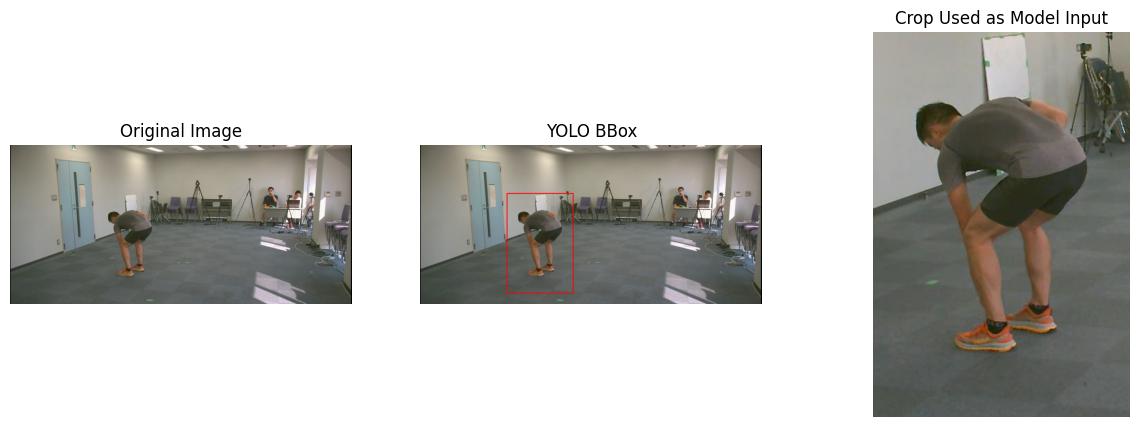

input tensor shape: torch.Size([1, 3, 112, 112])
prediction shape: torch.Size([1, 17, 3])


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import plotly.graph_objects as go


# ============================================================
# 0. 기본 설정
# ============================================================

# 2. 모델 뼈대(Architecture)의 인스턴스를 먼저 생성합니다.
model = ResNet(CnnBlock,[10,10,10,10,10])

saved_path = "/content/drive/MyDrive/my_model2_epoch_40.pth"
# 3. 전달받은 파라미터 파일(가중치)을 모델에 덮어씌웁니다.
model.load_state_dict(torch.load(saved_path))


IMAGE_SIZE = 112
YOLO_CONF = 0.25
CROP_MARGIN = 0.25


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# YOLO person detector
yolo_detector = YOLO("yolov8n.pt")


# ============================================================
# 1. H36M Skeleton 연결 정보
# ============================================================

H36M_BONES = [
    (0, 1), (1, 2), (2, 3),          # right leg
    (0, 4), (4, 5), (5, 6),          # left leg
    (0, 7), (7, 8), (8, 9), (9, 10), # spine / head
    (8, 11), (11, 12), (12, 13),     # left arm
    (8, 14), (14, 15), (15, 16)      # right arm
]

H36M_JOINT_NAMES = [
    "Pelvis",
    "R_Hip", "R_Knee", "R_Ankle",
    "L_Hip", "L_Knee", "L_Ankle",
    "Spine", "Thorax", "Neck", "Head",
    "L_Shoulder", "L_Elbow", "L_Wrist",
    "R_Shoulder", "R_Elbow", "R_Wrist"
]


# ============================================================
# 2. YOLO로 사람 영역 crop
# ============================================================

def crop_person_with_yolo(
    pil_img,
    yolo_detector,
    conf_thres=0.25,
    margin=0.25
):
    """
    PIL Image에서 사람 영역을 YOLO로 검출한 뒤 crop.

    return:
        crop_pil: crop된 PIL Image
        box: [x1, y1, x2, y2]
        detected: 사람 검출 성공 여부
    """

    img_rgb = np.array(pil_img.convert("RGB"))
    H, W = img_rgb.shape[:2]

    results = yolo_detector(img_rgb, conf=conf_thres, verbose=False)
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        print("YOLO detection failed. Use original image.")
        return pil_img, np.array([0, 0, W, H], dtype=np.int32), False

    xyxy = boxes.xyxy.detach().cpu().numpy()
    cls = boxes.cls.detach().cpu().numpy()
    conf = boxes.conf.detach().cpu().numpy()

    # COCO pretrained YOLO 기준 person class = 0
    person_mask = cls == 0

    if person_mask.sum() == 0:
        print("No person detected. Use original image.")
        return pil_img, np.array([0, 0, W, H], dtype=np.int32), False

    person_boxes = xyxy[person_mask]
    person_conf = conf[person_mask]

    # confidence 가장 높은 사람 1명 선택
    best_idx = np.argmax(person_conf)
    x1, y1, x2, y2 = person_boxes[best_idx]

    # margin 추가
    bw = x2 - x1
    bh = y2 - y1

    x1 -= bw * margin
    y1 -= bh * margin
    x2 += bw * margin
    y2 += bh * margin

    # 이미지 범위 제한
    x1 = int(max(0, x1))
    y1 = int(max(0, y1))
    x2 = int(min(W, x2))
    y2 = int(min(H, y2))

    if x2 <= x1 or y2 <= y1:
        print("Invalid bbox. Use original image.")
        return pil_img, np.array([0, 0, W, H], dtype=np.int32), False

    crop_rgb = img_rgb[y1:y2, x1:x2]
    crop_pil = Image.fromarray(crop_rgb)

    return crop_pil, np.array([x1, y1, x2, y2], dtype=np.int32), True


# ============================================================
# 3. 모델 입력 전처리
# ============================================================

def preprocess_pil_for_model(pil_img, img_size=112):
    """
    PIL Image → model input tensor
    output shape: (1, 3, img_size, img_size)
    """

    img = pil_img.convert("RGB")
    img = img.resize((img_size, img_size))

    img_np = np.array(img).astype(np.float32) / 255.0
    img_np = np.transpose(img_np, (2, 0, 1))  # HWC → CHW

    tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)

    return tensor


# ============================================================
# 4. 원본 이미지에 bbox 표시
# ============================================================

def draw_bbox_on_image(pil_img, box):
    img_rgb = np.array(pil_img.convert("RGB")).copy()
    x1, y1, x2, y2 = box

    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 0, 255), 3)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return Image.fromarray(img_rgb)


# ============================================================
# 5. Interactive 3D Pose 시각화
# ============================================================

def show_interactive_3d_pose(
    predictions,
    title="3D Pose Estimation Result - Interactive",
    marker_size=3,
    line_width=4,
    show_joint_text=True
):
    """
    predictions: torch.Tensor or np.ndarray
                 shape = (1, 17, 3) or (17, 3)
    """

    if isinstance(predictions, torch.Tensor):
        pose = predictions.squeeze().detach().cpu().numpy()
    else:
        pose = np.asarray(predictions).squeeze()

    pose = pose.astype(np.float32)

    if pose.shape != (17, 3):
        raise ValueError(f"Expected pose shape (17, 3), but got {pose.shape}")

    # pelvis 기준 정렬
    pose = pose - pose[0:1]

    x = pose[:, 0]
    y = pose[:, 1]
    z = pose[:, 2]

    fig = go.Figure()

    # 관절 점
    fig.add_trace(
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers+text" if show_joint_text else "markers",
            marker=dict(size=marker_size, color="red"),
            text=[str(i) for i in range(17)] if show_joint_text else None,
            textposition="top center",
            name="Joints",
            hovertext=H36M_JOINT_NAMES,
            hoverinfo="text"
        )
    )

    # 뼈대 선
    for i, j in H36M_BONES:
        fig.add_trace(
            go.Scatter3d(
                x=[x[i], x[j]],
                y=[y[i], y[j]],
                z=[z[i], z[j]],
                mode="lines",
                line=dict(color="blue", width=line_width),
                showlegend=False
            )
        )

    coords = np.stack([x, y, z], axis=1)
    center = coords.mean(axis=0)
    max_range = (coords.max(axis=0) - coords.min(axis=0)).max() / 2

    if max_range < 0.5:
        max_range = 0.5

    fig.update_layout(
        title=title,
        width=800,
        height=700,
        scene=dict(
            xaxis=dict(
                title="X Axis",
                range=[center[0] - max_range, center[0] + max_range]
            ),
            yaxis=dict(
                title="Y Axis",
                range=[center[1] - max_range, center[1] + max_range]
            ),
            zaxis=dict(
                title="Z Axis",
                range=[center[2] - max_range, center[2] + max_range]
            ),
            aspectmode="cube"
        )
    )

    fig.show()


# ============================================================
# 6. 전체 추론 함수
# ============================================================

def predict_pose_from_image_with_yolo_crop(
    model,
    image_path,
    yolo_detector,
    device,
    img_size=112,
    conf_thres=0.25,
    margin=0.25,
    show_input=True,
    show_3d=True
):
    """
    실제 이미지 1장에 대해:
    원본 이미지 → YOLO person crop → 112x112 전처리 → model 추론 → 3D pose 출력
    """

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # 1. 이미지 로드
    original_img = Image.open(image_path).convert("RGB")

    # 2. YOLO crop
    crop_img, box, detected = crop_person_with_yolo(
        pil_img=original_img,
        yolo_detector=yolo_detector,
        conf_thres=conf_thres,
        margin=margin
    )

    print("person detected:", detected)
    print("bbox:", box)

    # 3. bbox 표시 이미지
    bbox_img = draw_bbox_on_image(original_img, box)

    # 4. crop 결과 확인
    if show_input:
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(original_img)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(bbox_img)
        plt.title("YOLO BBox")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(crop_img)
        plt.title("Crop Used as Model Input")
        plt.axis("off")

        plt.show()

    # 5. 모델 입력 생성
    input_tensor = preprocess_pil_for_model(
        crop_img,
        img_size=img_size
    ).to(device)

    print("input tensor shape:", input_tensor.shape)

    # 6. 모델 추론
    model.eval()
    with torch.no_grad():
        predictions = model(input_tensor)

    print("prediction shape:", predictions.shape)

    # 7. 3D pose 시각화
    if show_3d:
        show_interactive_3d_pose(
            predictions,
            title="3D Pose Estimation Result - Interactive",
            marker_size=2,
            line_width=4,
            show_joint_text=True
        )

    return predictions, crop_img, box


# ============================================================
# 7. 사용 예시
# ============================================================
# 1. 이미지 불러오기
image_path = "/content/drive/MyDrive/machine_learning_team_project/jump_image3.jpg"

predictions, crop_img, box = predict_pose_from_image_with_yolo_crop(
    model=model,
    image_path=image_path,
    yolo_detector=yolo_detector,
    device=device,
    img_size=IMAGE_SIZE,
    conf_thres=YOLO_CONF,
    margin=CROP_MARGIN,
    show_input=True,
    show_3d=True
)

In [ ]:
import torch

model = ResNet(CnnBlock,[10,10,10,10,10])
model.eval()

dummy_input = torch.randn(1, 3, 112, 112)

# 3. tracing을 시작합니다! (가짜 데이터를 통과시키며 연산 과정을 녹화)
traced_model = torch.jit.trace(model, dummy_input)

# 4. 녹화된 모델을 .pt 파일로 저장합니다.
traced_model.save("climbing_model_scripted.pt")

print("TorchScript 변환 및 저장 완료!")

TorchScript 변환 및 저장 완료!


person detected: True
bbox: [ 38   0 533 357]


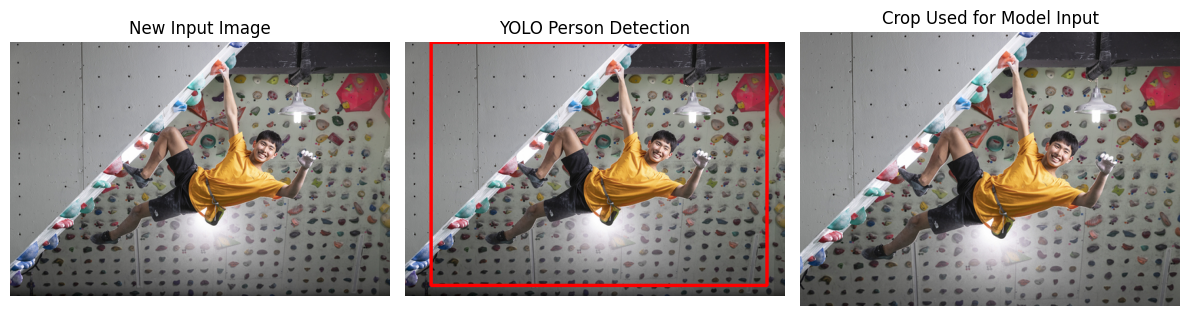

input tensor shape: torch.Size([1, 3, 112, 112])
prediction shape: torch.Size([1, 17, 3])


In [ ]:
# ============================================================
# 새 이미지 1장 → YOLO crop → 112x112 resize → model 추론 → 3D pose 출력
# ============================================================

!pip install -q ultralytics plotly

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import plotly.graph_objects as go


# ============================================================
# 0. 기본 설정
# ============================================================

IMAGE_SIZE = 112
YOLO_CONF = 0.25
CROP_MARGIN = 0.25

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

yolo_detector = YOLO("yolov8n.pt")


# ============================================================
# 1. H36M 관절 연결 정보
# ============================================================

H36M_BONES = [
    (0, 1), (1, 2), (2, 3),          # right leg
    (0, 4), (4, 5), (5, 6),          # left leg
    (0, 7), (7, 8), (8, 9), (9, 10), # spine/head
    (8, 11), (11, 12), (12, 13),     # left arm
    (8, 14), (14, 15), (15, 16)      # right arm
]

H36M_JOINT_NAMES = [
    "Pelvis",
    "R_Hip", "R_Knee", "R_Ankle",
    "L_Hip", "L_Knee", "L_Ankle",
    "Spine", "Thorax", "Neck", "Head",
    "L_Shoulder", "L_Elbow", "L_Wrist",
    "R_Shoulder", "R_Elbow", "R_Wrist"
]


# ============================================================
# 2. YOLO로 사람 영역 crop
# ============================================================

def crop_person_with_yolo(pil_img, yolo_detector, conf_thres=0.25, margin=0.25):
    img_rgb = np.array(pil_img.convert("RGB"))
    H, W = img_rgb.shape[:2]

    results = yolo_detector(img_rgb, conf=conf_thres, verbose=False)
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        print("사람 검출 실패: 원본 이미지를 그대로 사용합니다.")
        return pil_img, np.array([0, 0, W, H], dtype=np.int32), False

    xyxy = boxes.xyxy.detach().cpu().numpy()
    cls = boxes.cls.detach().cpu().numpy()
    conf = boxes.conf.detach().cpu().numpy()

    # COCO 기준 person class = 0
    person_mask = cls == 0

    if person_mask.sum() == 0:
        print("person class 검출 실패: 원본 이미지를 그대로 사용합니다.")
        return pil_img, np.array([0, 0, W, H], dtype=np.int32), False

    person_boxes = xyxy[person_mask]
    person_conf = conf[person_mask]

    best_idx = np.argmax(person_conf)
    x1, y1, x2, y2 = person_boxes[best_idx]

    # margin 추가
    bw = x2 - x1
    bh = y2 - y1

    x1 -= bw * margin
    y1 -= bh * margin
    x2 += bw * margin
    y2 += bh * margin

    x1 = int(max(0, x1))
    y1 = int(max(0, y1))
    x2 = int(min(W, x2))
    y2 = int(min(H, y2))

    crop_rgb = img_rgb[y1:y2, x1:x2]
    crop_pil = Image.fromarray(crop_rgb)

    return crop_pil, np.array([x1, y1, x2, y2], dtype=np.int32), True


# ============================================================
# 3. 모델 입력 전처리
# ============================================================

def preprocess_pil_for_model(pil_img, img_size=112):
    img = pil_img.convert("RGB")
    img = img.resize((img_size, img_size))

    img_np = np.array(img).astype(np.float32) / 255.0
    img_np = np.transpose(img_np, (2, 0, 1))  # HWC → CHW

    tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)

    return tensor


# ============================================================
# 4. bbox 시각화
# ============================================================

def draw_bbox_on_image(pil_img, box):
    img_rgb = np.array(pil_img.convert("RGB")).copy()
    x1, y1, x2, y2 = box

    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 0, 255), 3)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return Image.fromarray(img_rgb)


# ============================================================
# 5. 3D pose 인터랙티브 시각화
# ============================================================

def show_interactive_3d_pose(predictions, title="3D Pose Estimation Result"):
    if isinstance(predictions, torch.Tensor):
        pose = predictions.squeeze().detach().cpu().numpy()
    else:
        pose = np.asarray(predictions).squeeze()

    pose = pose.astype(np.float32)

    if pose.shape != (17, 3):
        raise ValueError(f"Expected shape (17, 3), but got {pose.shape}")

    # 0번 pelvis 기준으로 다시 정렬
    pose = pose - pose[0:1]

    x = pose[:, 0]
    y = pose[:, 1]
    z = pose[:, 2]

    fig = go.Figure()

    # 관절 점
    fig.add_trace(
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers+text",
            marker=dict(size=3, color="red"),
            text=[str(i) for i in range(17)],
            textposition="top center",
            name="Joints",
            hovertext=H36M_JOINT_NAMES,
            hoverinfo="text"
        )
    )

    # 뼈대 선
    for i, j in H36M_BONES:
        fig.add_trace(
            go.Scatter3d(
                x=[x[i], x[j]],
                y=[y[i], y[j]],
                z=[z[i], z[j]],
                mode="lines",
                line=dict(color="blue", width=4),
                showlegend=False
            )
        )

    coords = np.stack([x, y, z], axis=1)
    center = coords.mean(axis=0)
    max_range = (coords.max(axis=0) - coords.min(axis=0)).max() / 2

    if max_range < 0.5:
        max_range = 0.5

    fig.update_layout(
        title=title,
        width=750,
        height=650,
        scene=dict(
            xaxis=dict(title="X", range=[center[0] - max_range, center[0] + max_range]),
            yaxis=dict(title="Y", range=[center[1] - max_range, center[1] + max_range]),
            zaxis=dict(title="Z", range=[center[2] - max_range, center[2] + max_range]),
            aspectmode="cube"
        )
    )

    fig.show()


# ============================================================
# 6. 새 이미지 예측 함수
# ============================================================

def predict_new_image_pose(
    image_path,
    model,
    yolo_detector,
    device,
    image_size=112,
    conf_thres=0.25,
    margin=0.25,
    show_input=True,
    show_pose=True
):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"이미지 경로를 찾을 수 없습니다: {image_path}")

    # 1. 이미지 로드
    original_img = Image.open(image_path).convert("RGB")

    # 2. YOLO 사람 검출 + crop
    crop_img, box, detected = crop_person_with_yolo(
        pil_img=original_img,
        yolo_detector=yolo_detector,
        conf_thres=conf_thres,
        margin=margin
    )

    print("person detected:", detected)
    print("bbox:", box)

    # 3. 입력 확인
    if show_input:
        bbox_img = draw_bbox_on_image(original_img, box)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(original_img)
        plt.title("New Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(bbox_img)
        plt.title("YOLO Person Detection")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(crop_img)
        plt.title("Crop Used for Model Input")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    # 4. 112x112 tensor 변환
    input_tensor = preprocess_pil_for_model(
        crop_img,
        img_size=image_size
    ).to(device)

    print("input tensor shape:", input_tensor.shape)

    # 5. 모델 추론
    model.eval()
    with torch.no_grad():
        predictions = model(input_tensor)

    print("prediction shape:", predictions.shape)

    # 6. 3D skeleton 출력
    if show_pose:
        show_interactive_3d_pose(
            predictions,
            title="New Image 3D Pose Prediction"
        )

    return predictions, crop_img, box


image_path = "/content/drive/MyDrive/machine_learning_team_project/climbing_image.jpg"

predictions, crop_img, box = predict_new_image_pose(
    image_path=image_path,
    model=model,
    yolo_detector=yolo_detector,
    device=device,
    image_size=112,
    conf_thres=0.25,
    margin=0.25,
    show_input=True,
    show_pose=True
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ============================================================
# H36M Skeleton 연결 정보
# ============================================================

H36M_BONES = [
    (0, 1), (1, 2), (2, 3),
    (0, 4), (4, 5), (5, 6),
    (0, 7), (7, 8), (8, 9), (9, 10),
    (8, 11), (11, 12), (12, 13),
    (8, 14), (14, 15), (15, 16)
]


# ============================================================
# 이전 애니메이션 plt 스타일과 비슷한 정적 출력
# ============================================================

def show_new_image_pose_like_animation_style(
    crop_img,
    predictions,
    axis_limit=1.0,
    elev=15,
    azim=-70,
    show_joint_index=True,
    title="New Image 3D Pose Prediction"
):
    """
    crop_img: YOLO crop된 PIL Image 또는 numpy image
    predictions: model output, shape (1, 17, 3) or (17, 3)
    """

    # -----------------------------
    # 1. prediction → numpy
    # -----------------------------
    if isinstance(predictions, torch.Tensor):
        pose = predictions.squeeze().detach().cpu().numpy()
    else:
        pose = np.asarray(predictions).squeeze()

    pose = pose.astype(np.float32)

    if pose.shape != (17, 3):
        raise ValueError(f"Expected pose shape (17, 3), but got {pose.shape}")

    # pelvis 기준 정렬
    pose = pose - pose[0:1]

    x = pose[:, 0]
    y = pose[:, 1]
    z = pose[:, 2]

    # -----------------------------
    # 2. figure 구성
    # -----------------------------
    fig = plt.figure(figsize=(14, 6))

    # 왼쪽: 모델 입력 crop 이미지
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(crop_img)
    ax1.set_title("Model Input Crop")
    ax1.axis("off")

    # 오른쪽: 3D Pose
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.set_title(title)

    # 관절 점
    ax2.scatter(x, y, z, c="red", s=18, label="Pred")

    for i, j in H36M_BONES:
        ax2.plot(
            [x[i], x[j]],
            [y[i], y[j]],
            [z[i], z[j]],
            color="red",
            linewidth=2
        )

    # 축 설정
    ax2.set_xlim(-axis_limit, axis_limit)
    ax2.set_ylim(-axis_limit, axis_limit)
    ax2.set_zlim(-axis_limit, axis_limit)

    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    ax2.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()

person detected: True
bbox: [487 275 857 831]


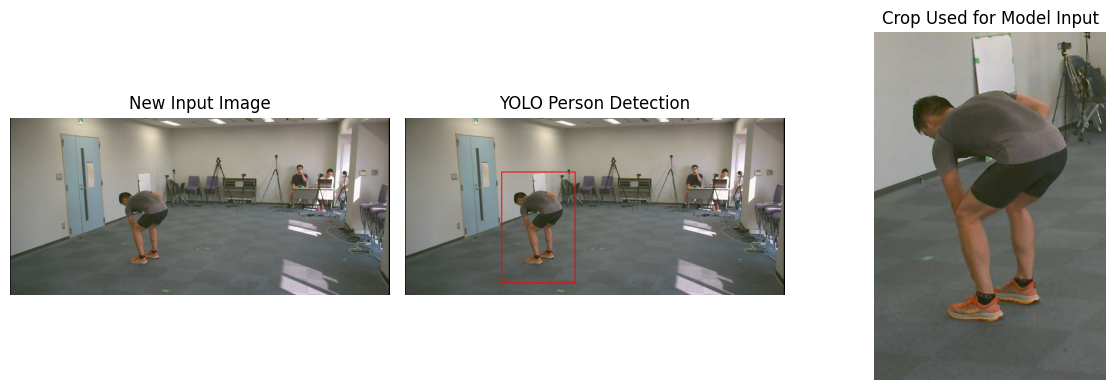

input tensor shape: torch.Size([1, 3, 112, 112])
prediction shape: torch.Size([1, 17, 3])


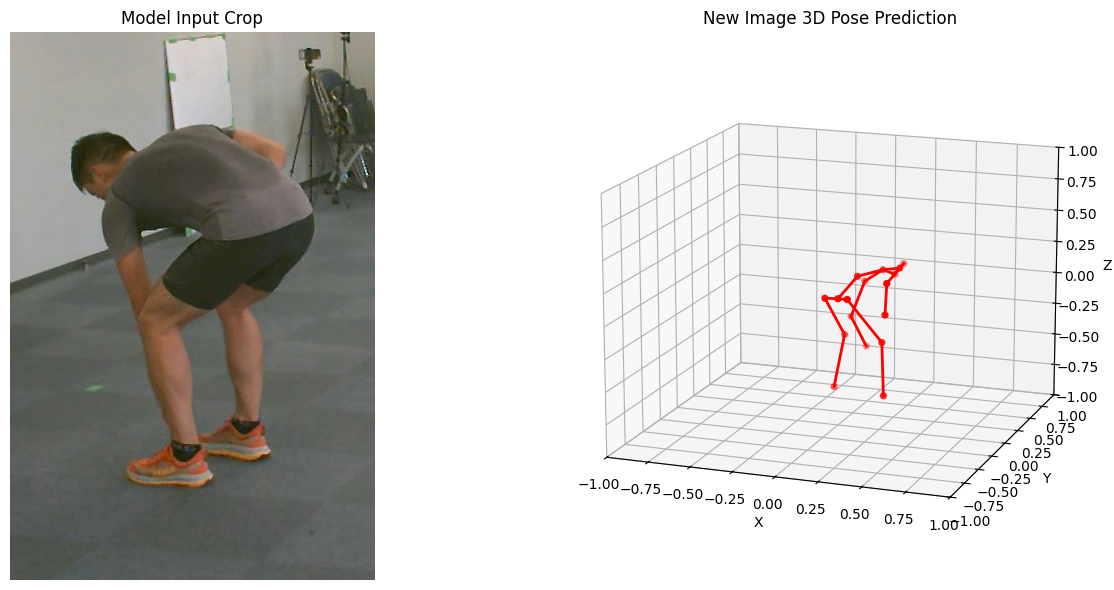

In [ ]:
image_path = "/content/drive/MyDrive/machine_learning_team_project/jump_image3.jpg"

predictions, crop_img, box = predict_new_image_pose(
    image_path=image_path,
    model=model,
    yolo_detector=yolo_detector,
    device=device,
    image_size=112,
    conf_thres=0.25,
    margin=0.25,
    show_input=True,
    show_pose=False
)

show_new_image_pose_like_animation_style(
    crop_img=crop_img,
    predictions=predictions,
    axis_limit=1.0,
    elev=15,
    azim=-70,
    show_joint_index=True,
    title="New Image 3D Pose Prediction"
)